In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt

In [10]:
pantries = pd.read_csv("pantries_old.csv")
gdf_pantry = gpd.GeoDataFrame(pantries,geometry=gpd.points_from_xy(pantries.Long, pantries.Lat),crs="EPSG:4326").to_crs(32618)
blocks = pd.read_csv("blocks.csv")
gdf_blocks = gpd.GeoDataFrame(blocks, geometry=gpd.points_from_xy(blocks.lon, blocks.lat), crs="EPSG:4326").to_crs(32618)

In [11]:
pantry_ids = gdf_pantry["Pantry"].tolist()

# Normalize lot size (acres)
gdf_pantry["lot_norm"] = gdf_pantry["lot_acres"] / gdf_pantry["lot_acres"].mean()


In [12]:
decay_rate = 0.765  # 23.5% drop per mile

def decay(d_miles):
    return decay_rate ** d_miles

beta_values = np.linspace(0, 1.2, 13)  # range of betas
sensitivity = {pid: [] for pid in pantry_ids}

alpha = 1.0  # keep decay constant for now

for beta in beta_values:
    # Recompute A values for this beta
    for pid in pantry_ids:
        pantry_row = gdf_pantry.loc[gdf_pantry["Pantry"] == pid].iloc[0]
        pantry_point = pantry_row.geometry
        lot_norm = pantry_row["lot_norm"]

        distances = gdf_blocks.geometry.distance(pantry_point) / 1609.34
        D_ij = decay(distances)

        gdf_blocks[f"A_{pid}"] = (D_ij ** alpha) * (lot_norm ** beta)

    # Normalize into probabilities
    A_cols = [f"A_{pid}" for pid in pantry_ids]
    A_sum = gdf_blocks[A_cols].sum(axis=1)
    
    for pid in pantry_ids:
        gdf_blocks[f"P_{pid}"] = gdf_blocks[f"A_{pid}"] / A_sum

    # Compute demand for this beta
    for pid in pantry_ids:
        sensitivity[pid].append(gdf_blocks[f"P_{pid}"].sum())


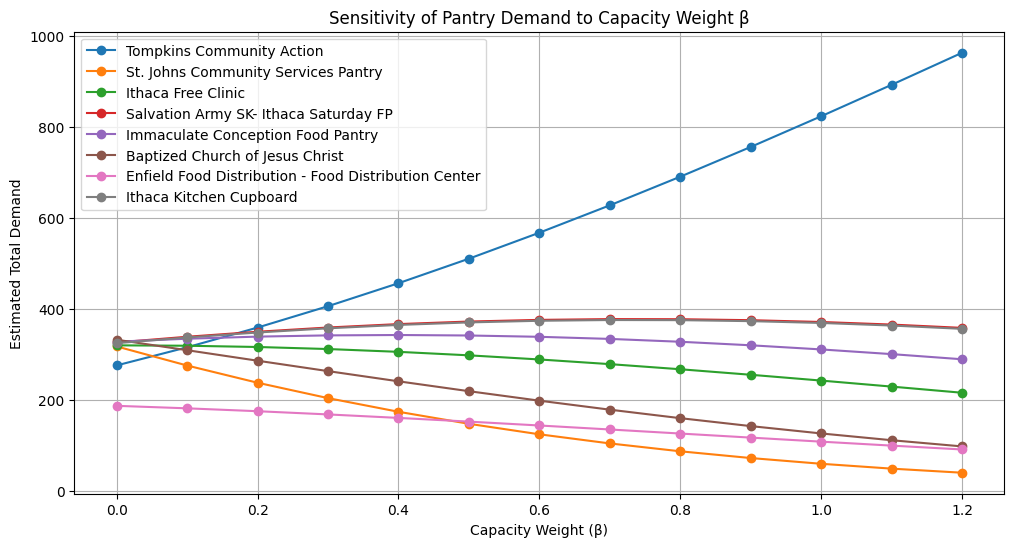

In [13]:
plt.figure(figsize=(12, 6))

for pid in pantry_ids:
    plt.plot(beta_values, sensitivity[pid], marker='o', label=pid)

plt.xlabel("Capacity Weight (β)")
plt.ylabel("Estimated Total Demand")
plt.title("Sensitivity of Pantry Demand to Capacity Weight β")
plt.legend()
plt.grid(True)
plt.show()
